In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import shutil

# Unzip data to Colab speed storage
!unzip -q "/content/drive/MyDrive/plant_disease_detection.zip" -d "/content/"

# Folder ke andar move karein
os.chdir('/content/plant_disease_detection')

# Check karein ke train, valid, test folders dikh rahe hain
print("Folders in dataset:", os.listdir('.'))

Folders in dataset: ['train_plant_diease.ipynb', 'test', 'train', 'valid']


In [5]:
import os

# 1. Purani file delete karein
!rm -f /content/plant_disease_detection/train_plant_diease.ipynb

# 2. Sahi path par directory set karein
os.chdir('/content/plant_disease_detection')

# 3. Check karein ke folder mein files agayi hain
!ls

test  train  valid


In [6]:
# Notebook ki copy ko folder ke andar save karne ke liye ye code run karein
!cp /content/drive/MyDrive/Colab\ Notebooks/Plant_Disease_Training.ipynb /content/plant_disease_detection/

# Plant Disease Prediction
### Dataset
**Dataset Link:** [New Plant Diseases Dataset (Kaggle)](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Data Preprocessing
Training Image preprocessing


In [8]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 70295 files belonging to 38 classes.


Validation Image Preprocessing

In [9]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [10]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [11]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[254.   254.   254.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]]

  [[254.   254.   254.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]]

  [[255.   255.   255.  ]
   [254.   254.   254.  ]
   [253.75 253.75 253.75]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]]

  ...

  [[251.25 245.75 243.75]
   [144.25 125.25 122.75]
   [ 70.    41.25  31.5 ]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]]

  [[223.   216.5  208.75]
   [168.75 151.25 145.75]
   [ 66.    31.5   25.25]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   255.  ]]

  [[251.   252.75 241.  ]
   [252.75 247.5  238.25]
   [255.   247.5  242.5 ]
   ...
   [255.   255.   255.  ]
   [255.   255.   255.  ]
   [255.   255.   25

In [12]:
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Dropout
from  tensorflow.keras.models import Sequential

In [13]:
model = Sequential()

In [14]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [16]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [17]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [18]:
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [19]:
model.add(Dropout(0.25)) #to   avoid overfitting

In [20]:
model.add(Flatten())

In [21]:
model.add(Dense(units=1500 ,activation='relu'))

In [22]:
model.add(Dropout(0.4))

In [23]:

#Output Layer
model.add(Dense(units=38,activation='softmax'))

Compiling and Training Phase

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 166s 68ms/step - accuracy: 0.6142 - loss: 1.3085 - val_accuracy: 0.8682 - val_loss: 0.4175
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 68ms/step - accuracy: 0.8672 - loss: 0.4215 - val_accuracy: 0.9126 - val_loss: 0.2668
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9177 - loss: 0.2524 - val_accuracy: 0.9258 - val_loss: 0.2428
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9427 - loss: 0.1779 - val_accuracy: 0.9425 - val_loss: 0.1745
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 137s 62ms/step - accuracy: 0.9567 - loss: 0.1318 - val_accuracy: 0.9438 - val_loss: 0.1833
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9657 - loss: 0.1046 - val_accuracy: 0.9575 - val_loss: 0.1341
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - accuracy: 0.9728 - loss: 0.0822 - val_accuracy: 0.9655 - val_loss: 0.1169
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 140s 64ms/step - accuracy: 

Evaluating Model

In [27]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9925 - loss: 0.0279
Training accuracy: 0.9925457239151001


In [28]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9693 - loss: 0.1107
Validation accuracy: 0.9692692756652832


Saving Model

In [29]:
model.save("trained_model.keras")

In [30]:
training_history.history

{'accuracy': [0.6142115592956543,
  0.8672167062759399,
  0.9176754951477051,
  0.9426701664924622,
  0.956682562828064,
  0.9656732082366943,
  0.9728003144264221,
  0.9774237275123596,
  0.9795860052108765,
  0.9823458194732666],
 'loss': [1.3084989786148071,
  0.42151203751564026,
  0.25236448645591736,
  0.17793937027454376,
  0.13182972371578217,
  0.10461683571338654,
  0.08222956210374832,
  0.06817549467086792,
  0.06402573734521866,
  0.054628387093544006],
 'val_accuracy': [0.8681994080543518,
  0.9126451015472412,
  0.9257910251617432,
  0.9425221681594849,
  0.9437741637229919,
  0.9574891924858093,
  0.965513288974762,
  0.9615297317504883,
  0.9650011658668518,
  0.9692692756652832],
 'val_loss': [0.41752102971076965,
  0.266767293214798,
  0.24283553659915924,
  0.17449955642223358,
  0.18334399163722992,
  0.13413359224796295,
  0.11686377972364426,
  0.13055750727653503,
  0.1157054454088211,
  0.11069650202989578]}

In [31]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

Accuracy Visualization

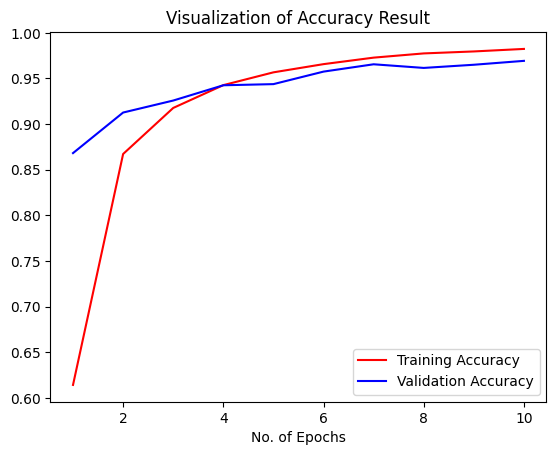

In [32]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

Some other metrics for model evaluation


In [33]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [35]:
y_pred = model.predict(test_set)
y_pred,y_pred

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step


(array([[1.0000000e+00, 1.2554366e-08, 1.8226020e-12, ..., 2.3428829e-17,
         9.8864329e-17, 5.7857483e-15],
        [9.9999952e-01, 1.3448563e-07, 2.1188483e-12, ..., 5.7281180e-16,
         2.3882462e-15, 2.0011953e-14],
        [1.0000000e+00, 2.4657335e-10, 5.2099879e-15, ..., 1.7175422e-21,
         6.7489537e-19, 3.7292492e-17],
        ...,
        [3.5843137e-11, 1.6335145e-11, 2.6117604e-09, ..., 3.2977432e-12,
         2.1686373e-11, 9.9999952e-01],
        [2.9829255e-12, 5.0966254e-14, 2.2469165e-11, ..., 3.6833774e-13,
         1.4528913e-12, 9.9999988e-01],
        [1.1583757e-14, 6.7129383e-16, 2.0702563e-15, ..., 2.1312269e-16,
         5.7152037e-14, 9.9999976e-01]], dtype=float32),
 array([[1.0000000e+00, 1.2554366e-08, 1.8226020e-12, ..., 2.3428829e-17,
         9.8864329e-17, 5.7857483e-15],
        [9.9999952e-01, 1.3448563e-07, 2.1188483e-12, ..., 5.7281180e-16,
         2.3882462e-15, 2.0011953e-14],
        [1.0000000e+00, 2.4657335e-10, 5.2099879e-15, ...,

In [36]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [38]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [39]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [46]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(Y_true,predicted_categories,target_names = class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.98      0.95       504
                                 Apple___Black_rot       0.95      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.98      0.97      0.98       440
                                   Apple___healthy       0.97      0.95      0.96       502
                               Blueberry___healthy       0.95      0.99      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.86      0.91       410
                       Corn_(maize)___Common_rust_       0.94      0.99      0.97       477
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.98      0.

In [48]:
cm = confusion_matrix(Y_true,predicted_categories)
cm.shape

(38, 38)

Confusion Matrix Visualization

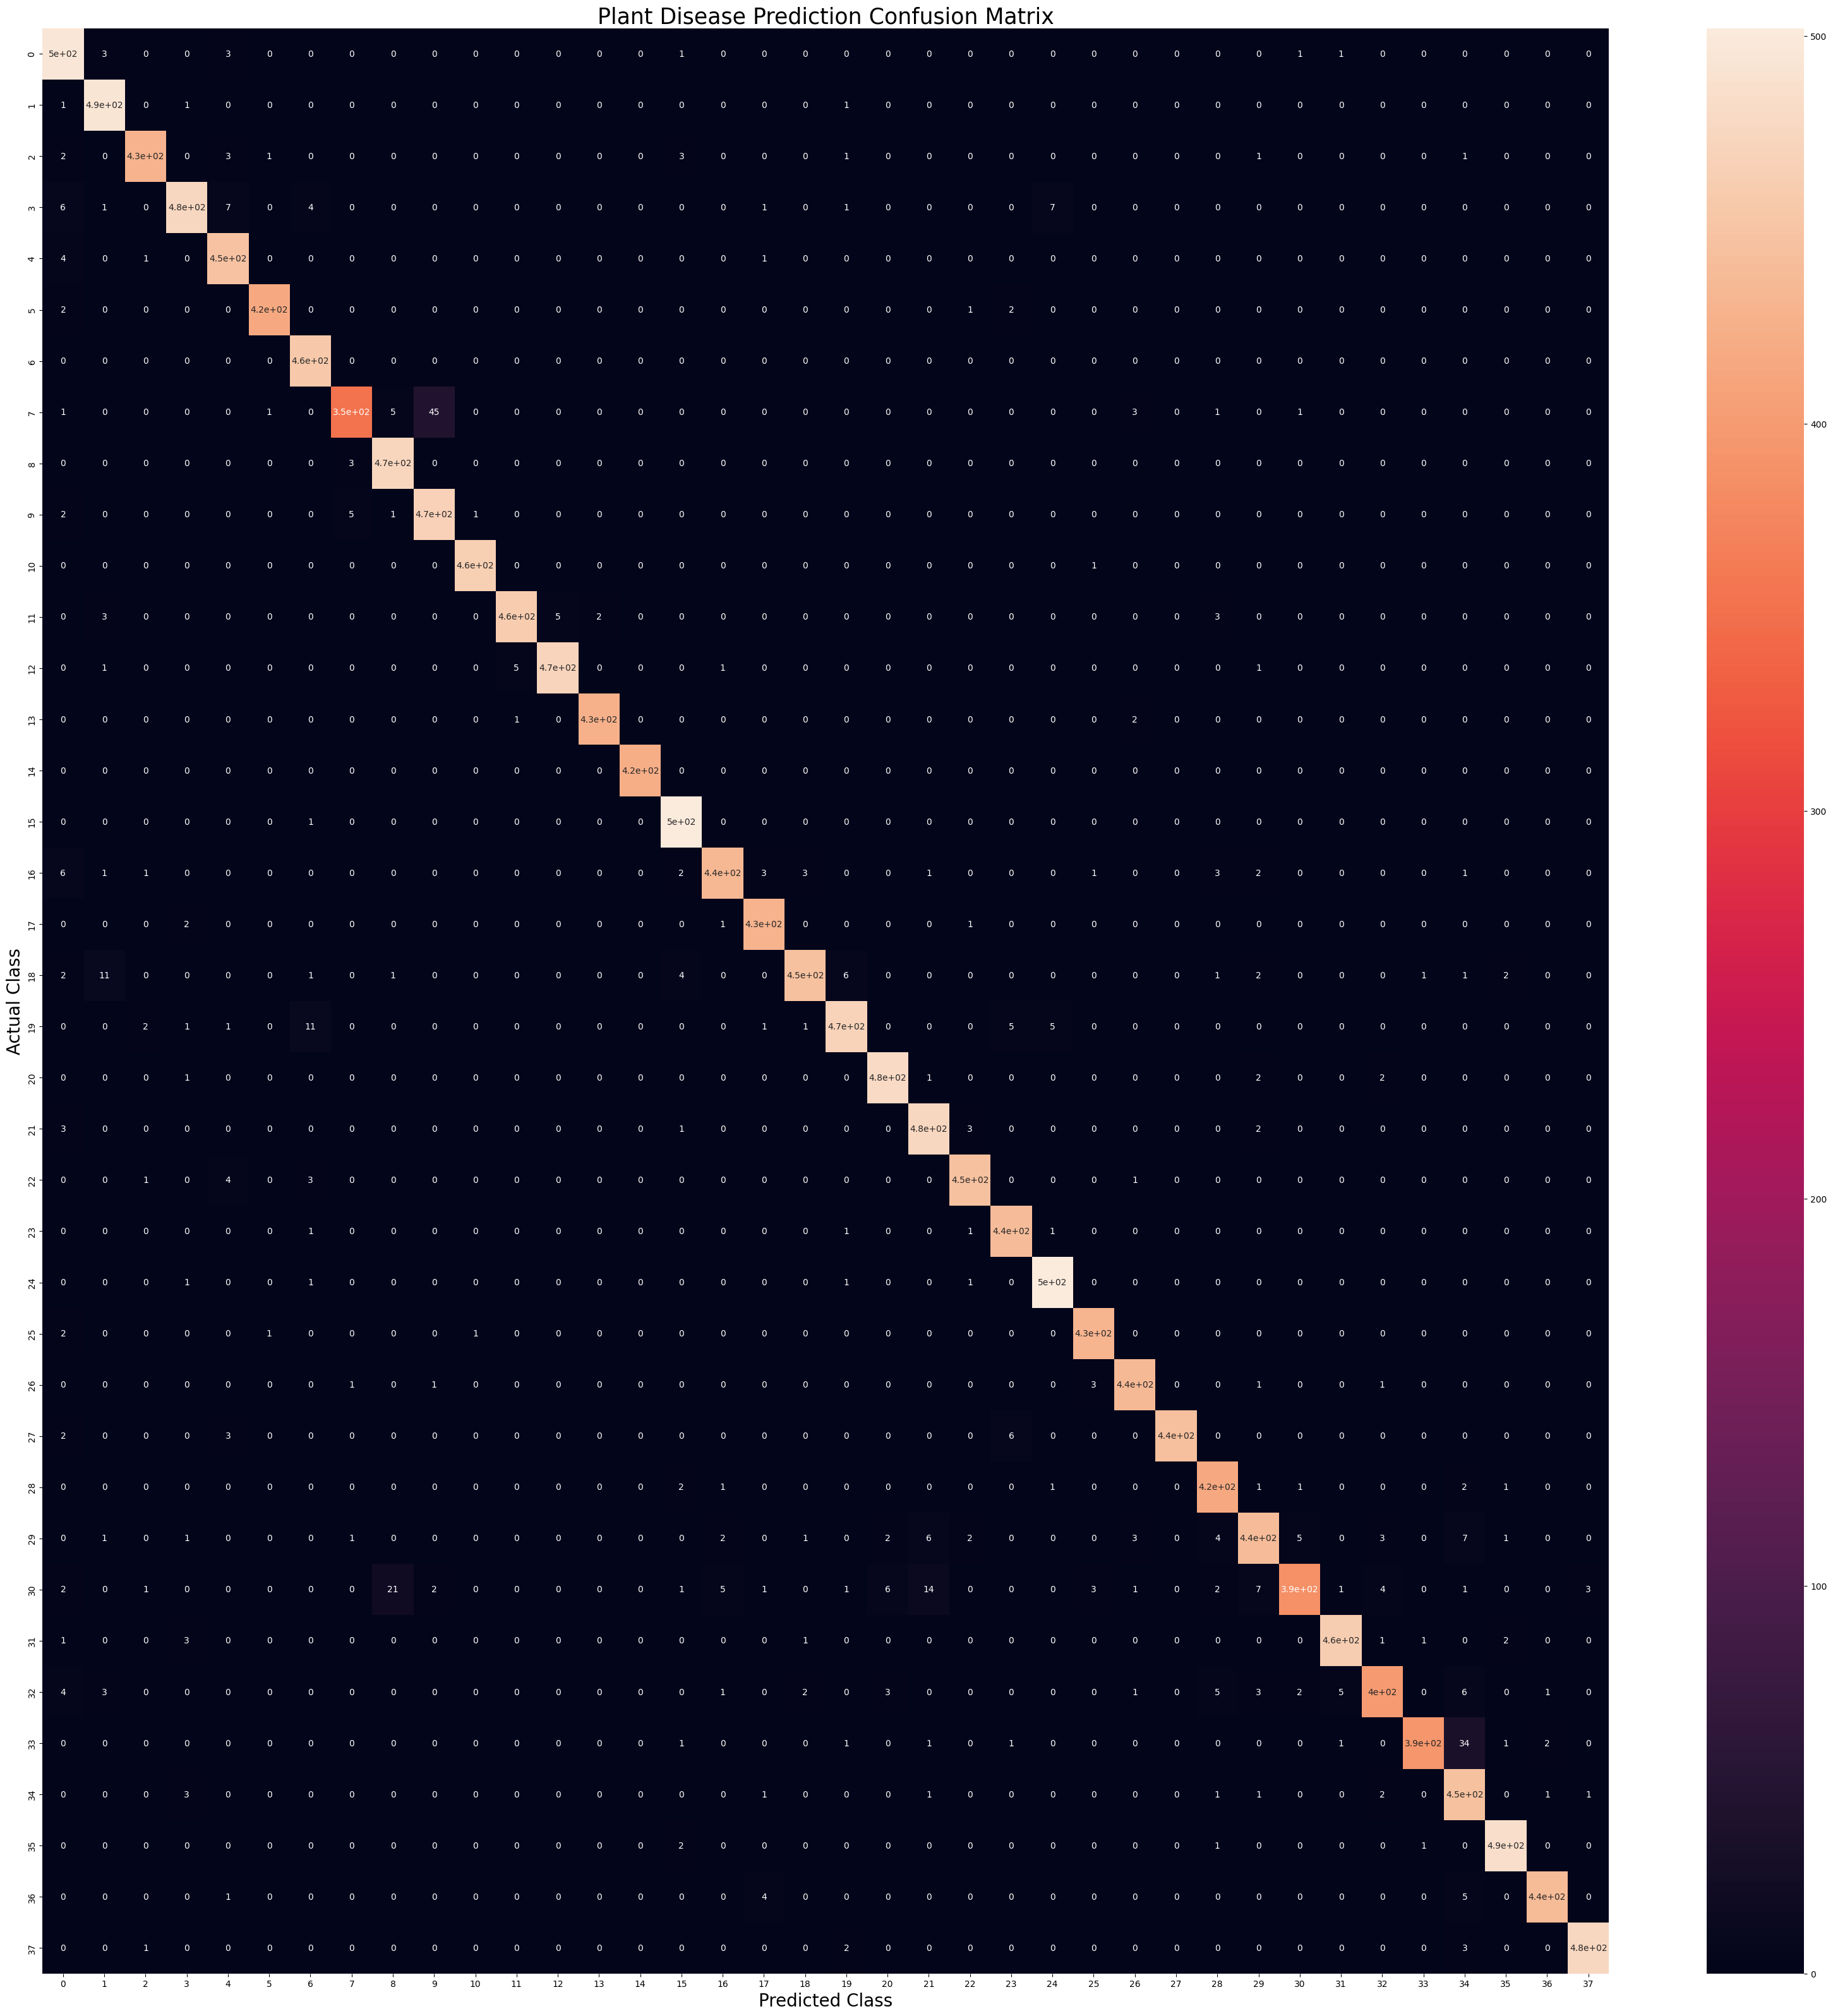

In [49]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

In [51]:
from google.colab import files

# 1. Model file
files.download('/content/plant_disease_detection/trained_model.keras')

# 2. Training notebook
files.download('/content/plant_disease_detection/Plant_Disease_Training.ipynb')

# 3. Training history JSON file
files.download('/content/plant_disease_detection/training_hist.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>